In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.cm as cm
from matplotlib import colors
from sklearn.decomposition import PCA
import tools
import importlib
import os
importlib.reload(tools)
import pyproj
from shapely.geometry import box
from shapely.ops import transform
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [2]:
morphotopes = gpd.read_parquet('/data/uscuni-evolution/all_joined_nl.parquet')

In [3]:
buildings = gpd.read_parquet("/data/uscuni-ulce/extension/netherlands/clean_3035.parquet")

In [4]:
def city_filter (centre_coords,buffer):
    centre = pd.DataFrame((centre_coords,), columns=["y", "x"])
    centre = gpd.GeoSeries(
        gpd.points_from_xy(centre["x"], centre["y"], crs="epsg:4326")
    ).to_crs(epsg=3035)
    
    city =buildings[buildings.within(centre.buffer(buffer).iloc[0])]
    city = gpd.sjoin(city,morphotopes,how="inner",predicate='intersects') 
    return city

In [5]:
def filter_morphotopes (centre_coords,buffer):
    centre = pd.DataFrame((centre_coords,), columns=["y", "x"])
    centre = gpd.GeoSeries(
        gpd.points_from_xy(centre["x"], centre["y"], crs="epsg:4326")
    ).to_crs(epsg=3035)
    
    city =morphotopes[morphotopes.within(centre.buffer(buffer).iloc[0])]
    return city

In [15]:
amsterdam = filter_morphotopes((52.36653681505743, 4.902419765879627),5_000)

In [16]:
amsterdam["year_mode"].unique()

<IntervalArray>
[(1930, 1940], (1950, 1960], (1980, 1990], (1970, 1980], (1920, 1930],
 (1990, 2000], (2010, 2020], (1960, 1970], (1910, 1920], (1900, 1910],
 (1880, 1890], (1870, 1880], (1890, 1900], (1940, 1950], (2000, 2010],
 (1740, 1750], (1730, 1740], (1640, 1650], (1770, 1780], (1760, 1770],
 (1720, 1730], (1750, 1760], (1610, 1620], (2020, 2030], (1000, 1010],
 (1850, 1860], (1860, 1870], (1810, 1820], (1790, 1800], (1670, 1680],
 (1690, 1700], (1800, 1810], (1660, 1670], (1700, 1710], (1680, 1690]]
Length: 35, dtype: interval[int64, right]

In [17]:
level_3_color_dict = {
    1: "#4069BC",
    2: "#7CBAE4",
    3: "#E69C63",
    4: "#eec1d5",
    5: "#E0665F",
    6: "#ECBF43",
    7: "#b2cd32",
    8: "#1F943E"
}

In [18]:
def plot_cumulative(city_gdf):
    # ------------------------------------------------------------------
    # 3. Setup 4x4 Grid of Subplots
    # ------------------------------------------------------------------
    
    sorted_intervals = sorted(city_gdf["year_mode"].unique())
    fig, axes = plt.subplots(7,5, figsize=(22, 20))
    axes = axes.flatten()  # Convert matrix to list for easy iteration
    
    # ------------------------------------------------------------------
    # 4. The Cumulative Plotting Loop
    # ------------------------------------------------------------------
    for i, current_interval in enumerate(sorted_intervals):
        ax = axes[i]
        
        # Generate the cumulative dataset for this time period
        intervals_up_to_now = sorted_intervals[:i+1]
        cumulative_df = city_gdf[city_gdf["year_mode"].isin(intervals_up_to_now)]
        
        # LAYER 1: Ghost Footprints (Light gray background of ALL buildings for context)
        city_gdf.plot(ax=ax, color="#EAEAEA", edgecolor="none", zorder=1)
        
        # LAYER 2: The buildings active at this time, colored by taxonomy
        # CHANGE: We now use the dictionary mapping directly via color=
        cumulative_df.plot(
            ax=ax, 
            color=cumulative_df["level_3_label"].map(level_3_color_dict),
            edgecolor="none", 
            zorder=2
        )
        
        # Stylize individual subplot
        ax.set_title(f"Up to {current_interval.right}", fontsize=15, fontweight="bold")
        ax.set_axis_off()
    
    
    # Adjust layout to make room for titles and the bottom legend
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])

In [19]:
def plot_non_cum(city_gdf):
    city_gdf["level_3_label"] = city_gdf["level_3_label"].astype(int)

    sorted_intervals = sorted(city_gdf["year_mode"].unique())
    
    fig, axes = plt.subplots(7,5, figsize=(22, 20))
    axes = axes.flatten()  # Convert matrix to list for easy iteration
    
    # ------------------------------------------------------------------
    # 4. The Non-Cumulative Plotting Loop
    # ------------------------------------------------------------------
    for i, current_interval in enumerate(sorted_intervals):
        ax = axes[i]
        
        # CHANGE: Filter for ONLY the buildings built in this specific interval
        current_df = city_gdf[city_gdf["year_mode"] == current_interval]
        
        # LAYER 1: Ghost Footprints (Light gray background of ALL buildings for context)
        city_gdf.plot(ax=ax, color="#EAEAEA", edgecolor="none", zorder=1)
        
        # LAYER 2: Only the buildings unique to this specific era
        current_df.plot(
            ax=ax, 
            color=current_df["level_3_label"].map(level_3_color_dict),
            edgecolor="none", 
            zorder=2
        )
        
        # Stylize individual subplot (Title changed to show the precise bracket)
        ax.set_title(f"{current_interval.left} — {current_interval.right}", fontsize=15, fontweight="bold")
        ax.set_axis_off()
    
    
    
    # Adjust layout to make room for titles and the bottom legend
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])

/home/eliska/evolution/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


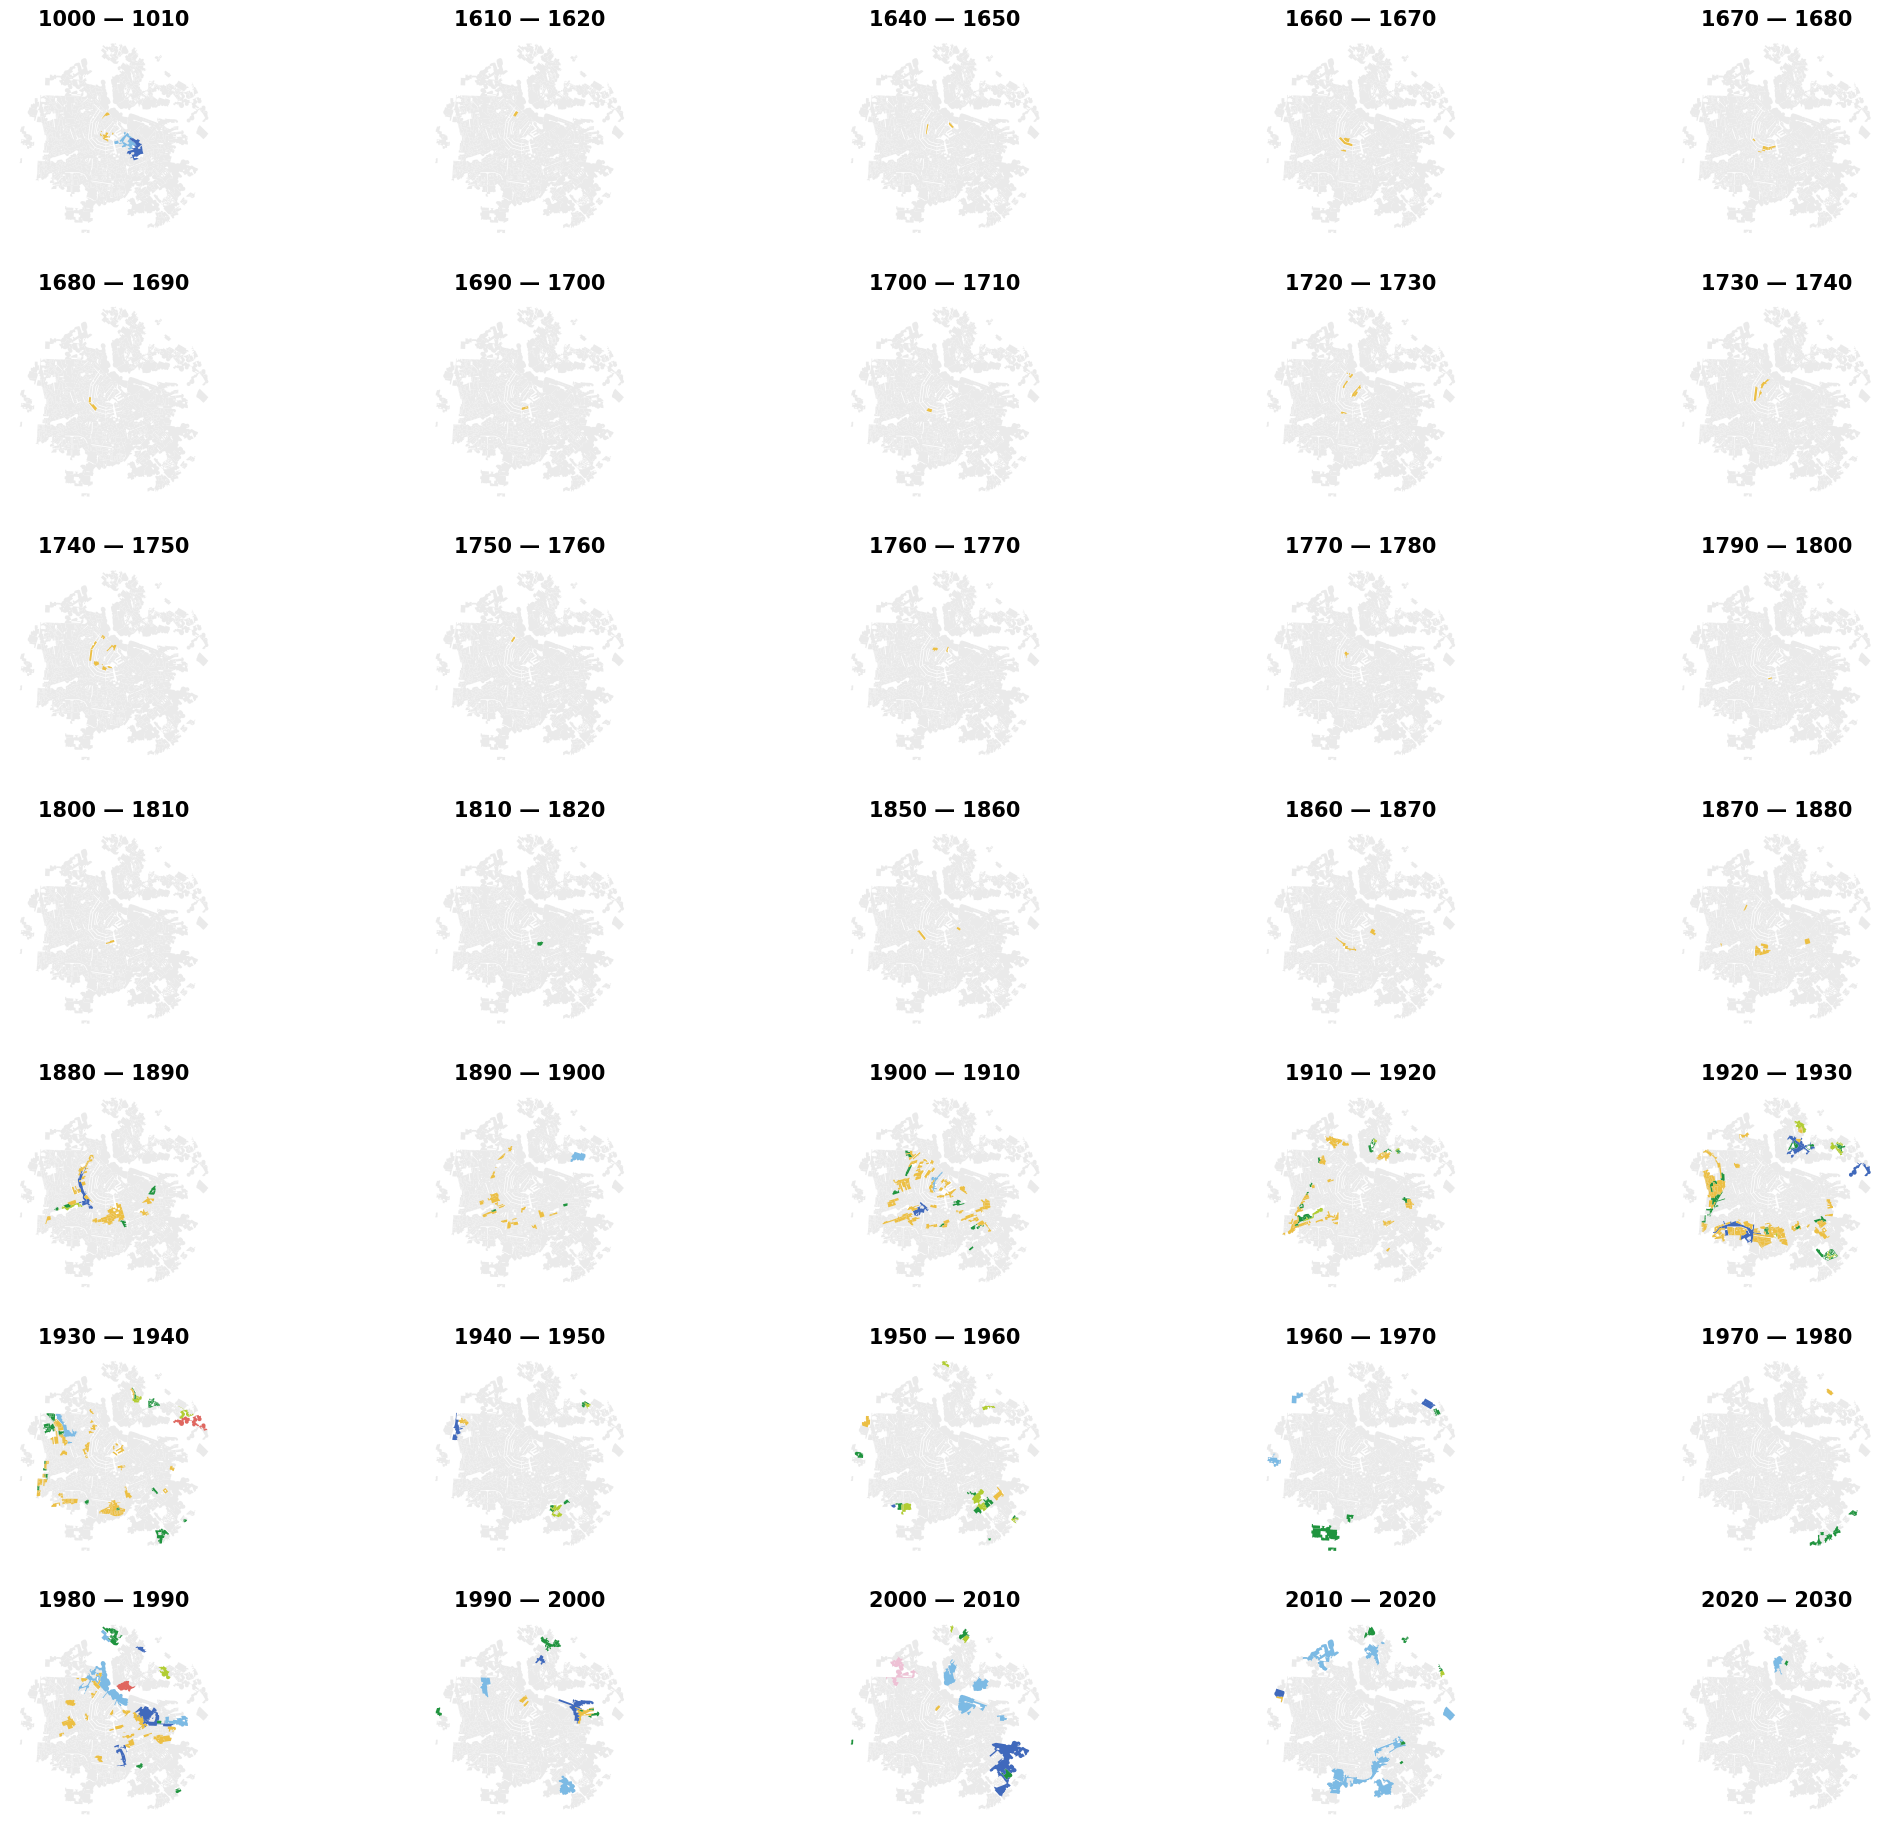

In [20]:
plot_non_cum(amsterdam)

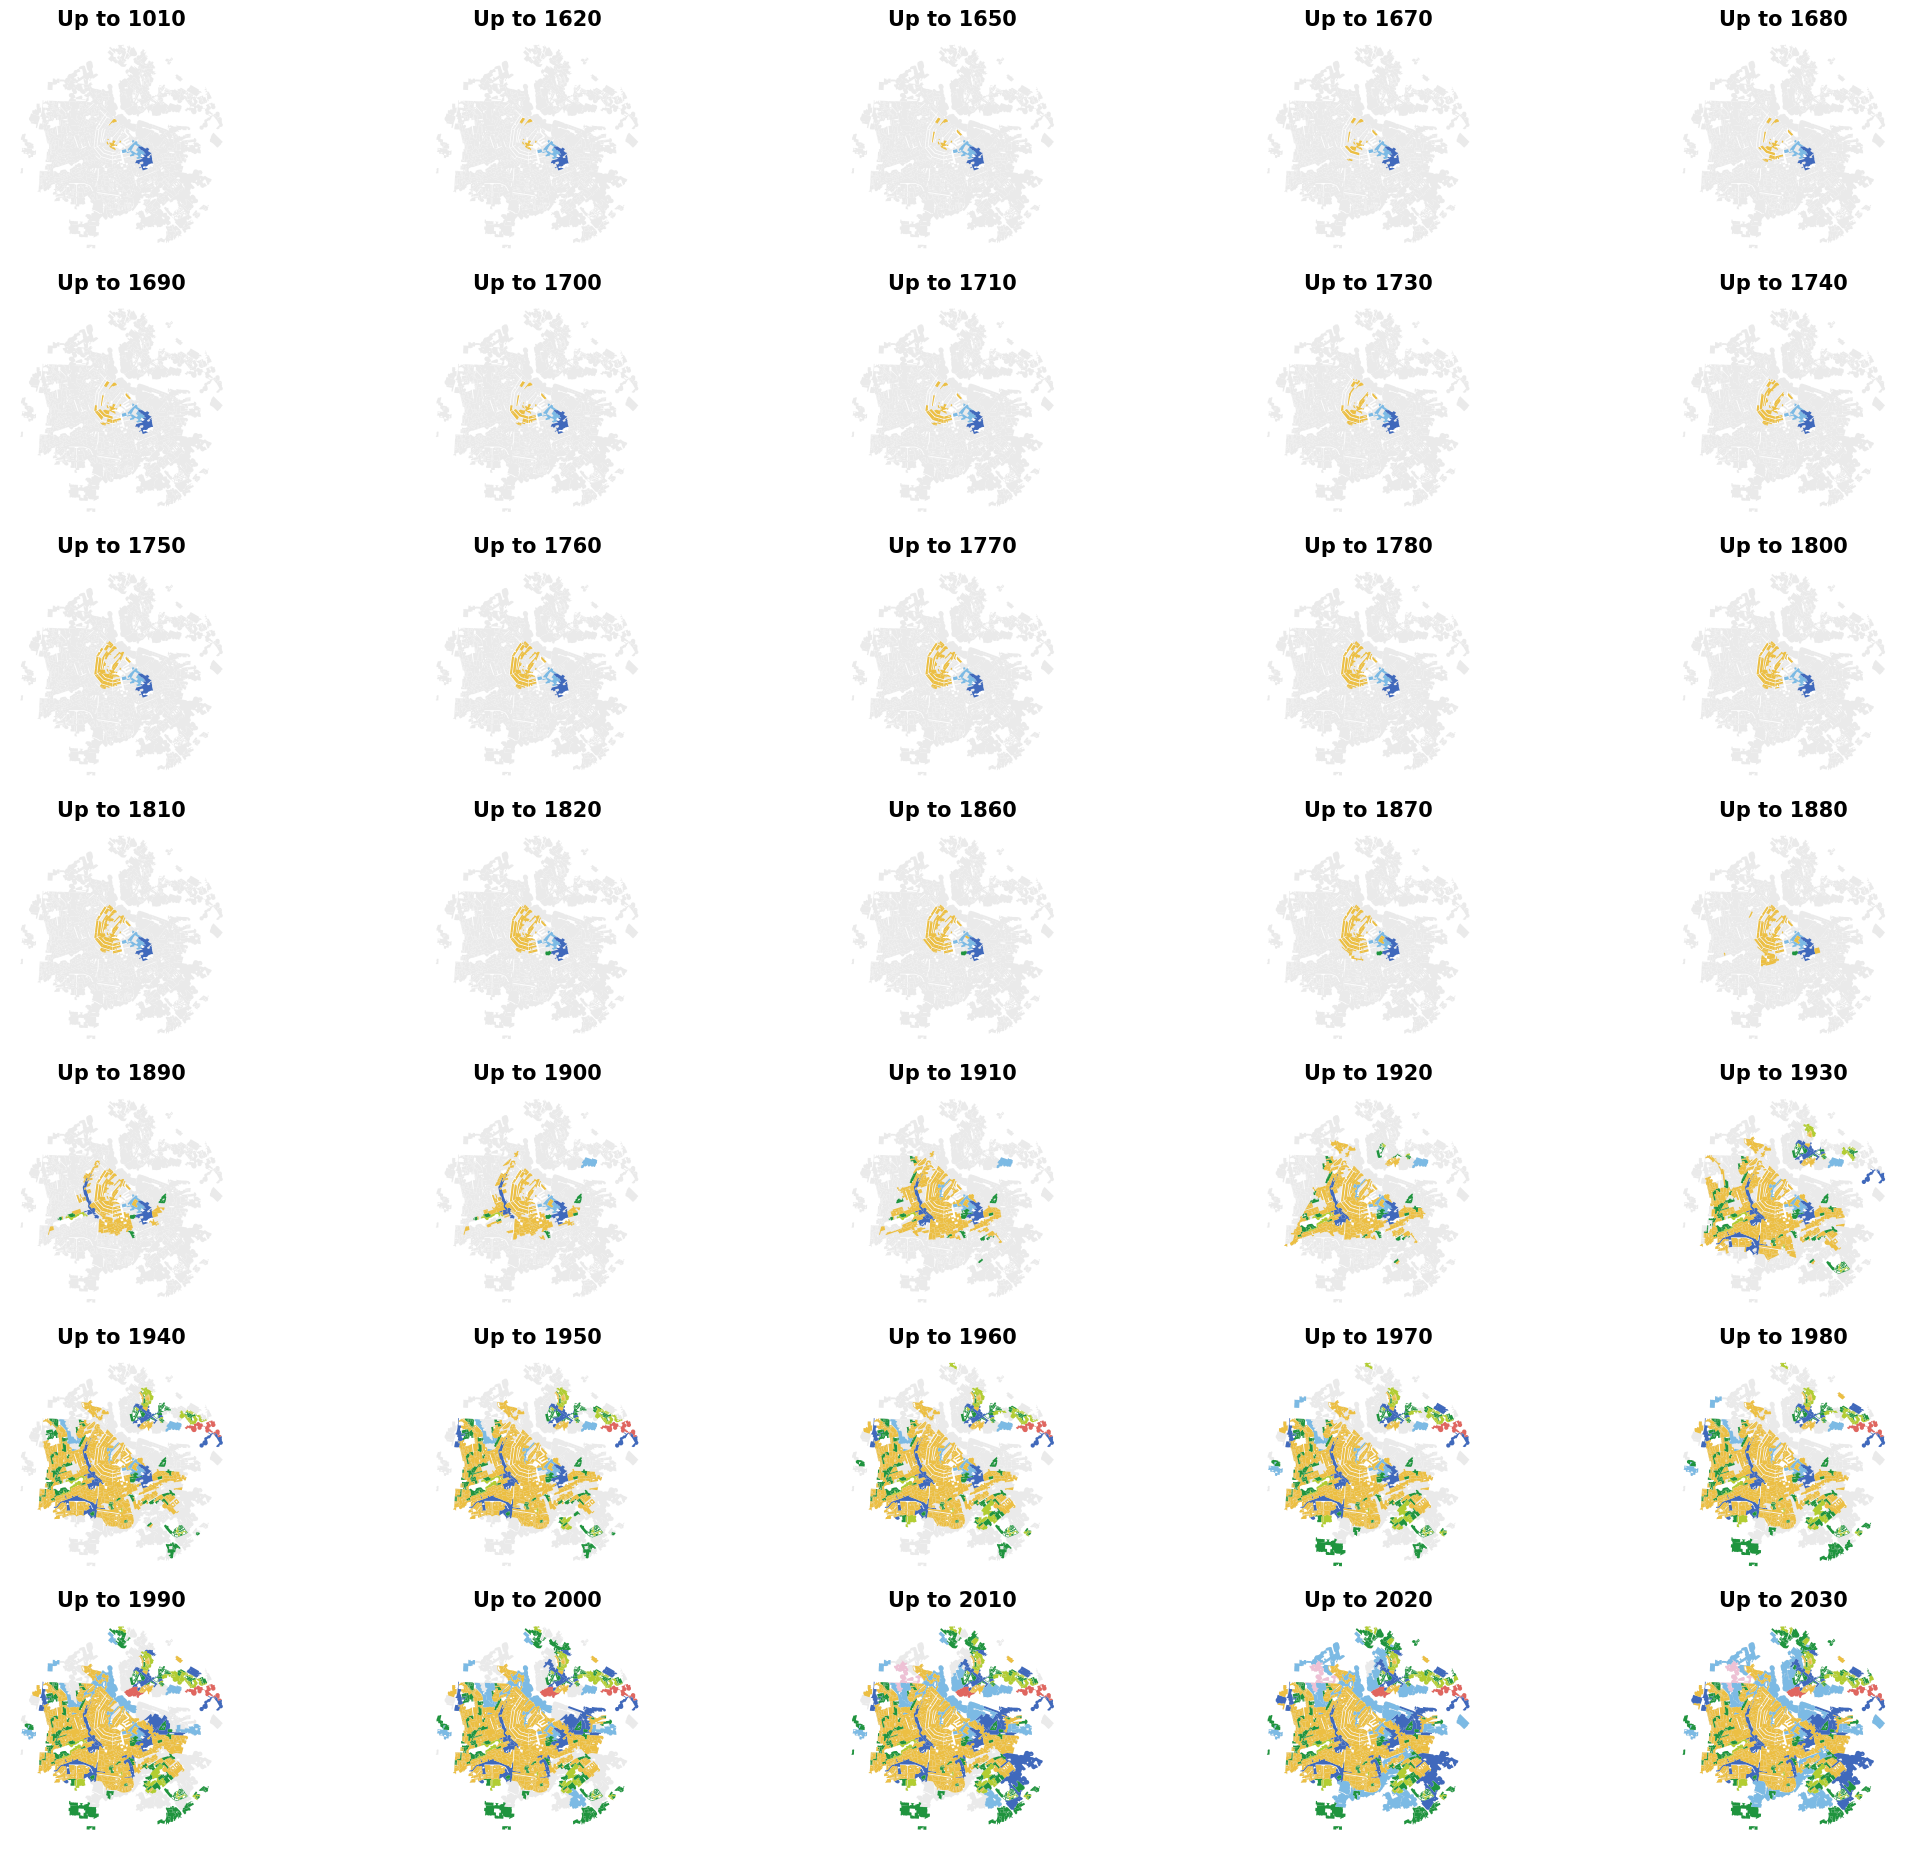

In [21]:
plot_cumulative(amsterdam)

In [22]:
groningen = filter_morphotopes((53.2174612195596, 6.630721756430745),5_000)

/home/eliska/evolution/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


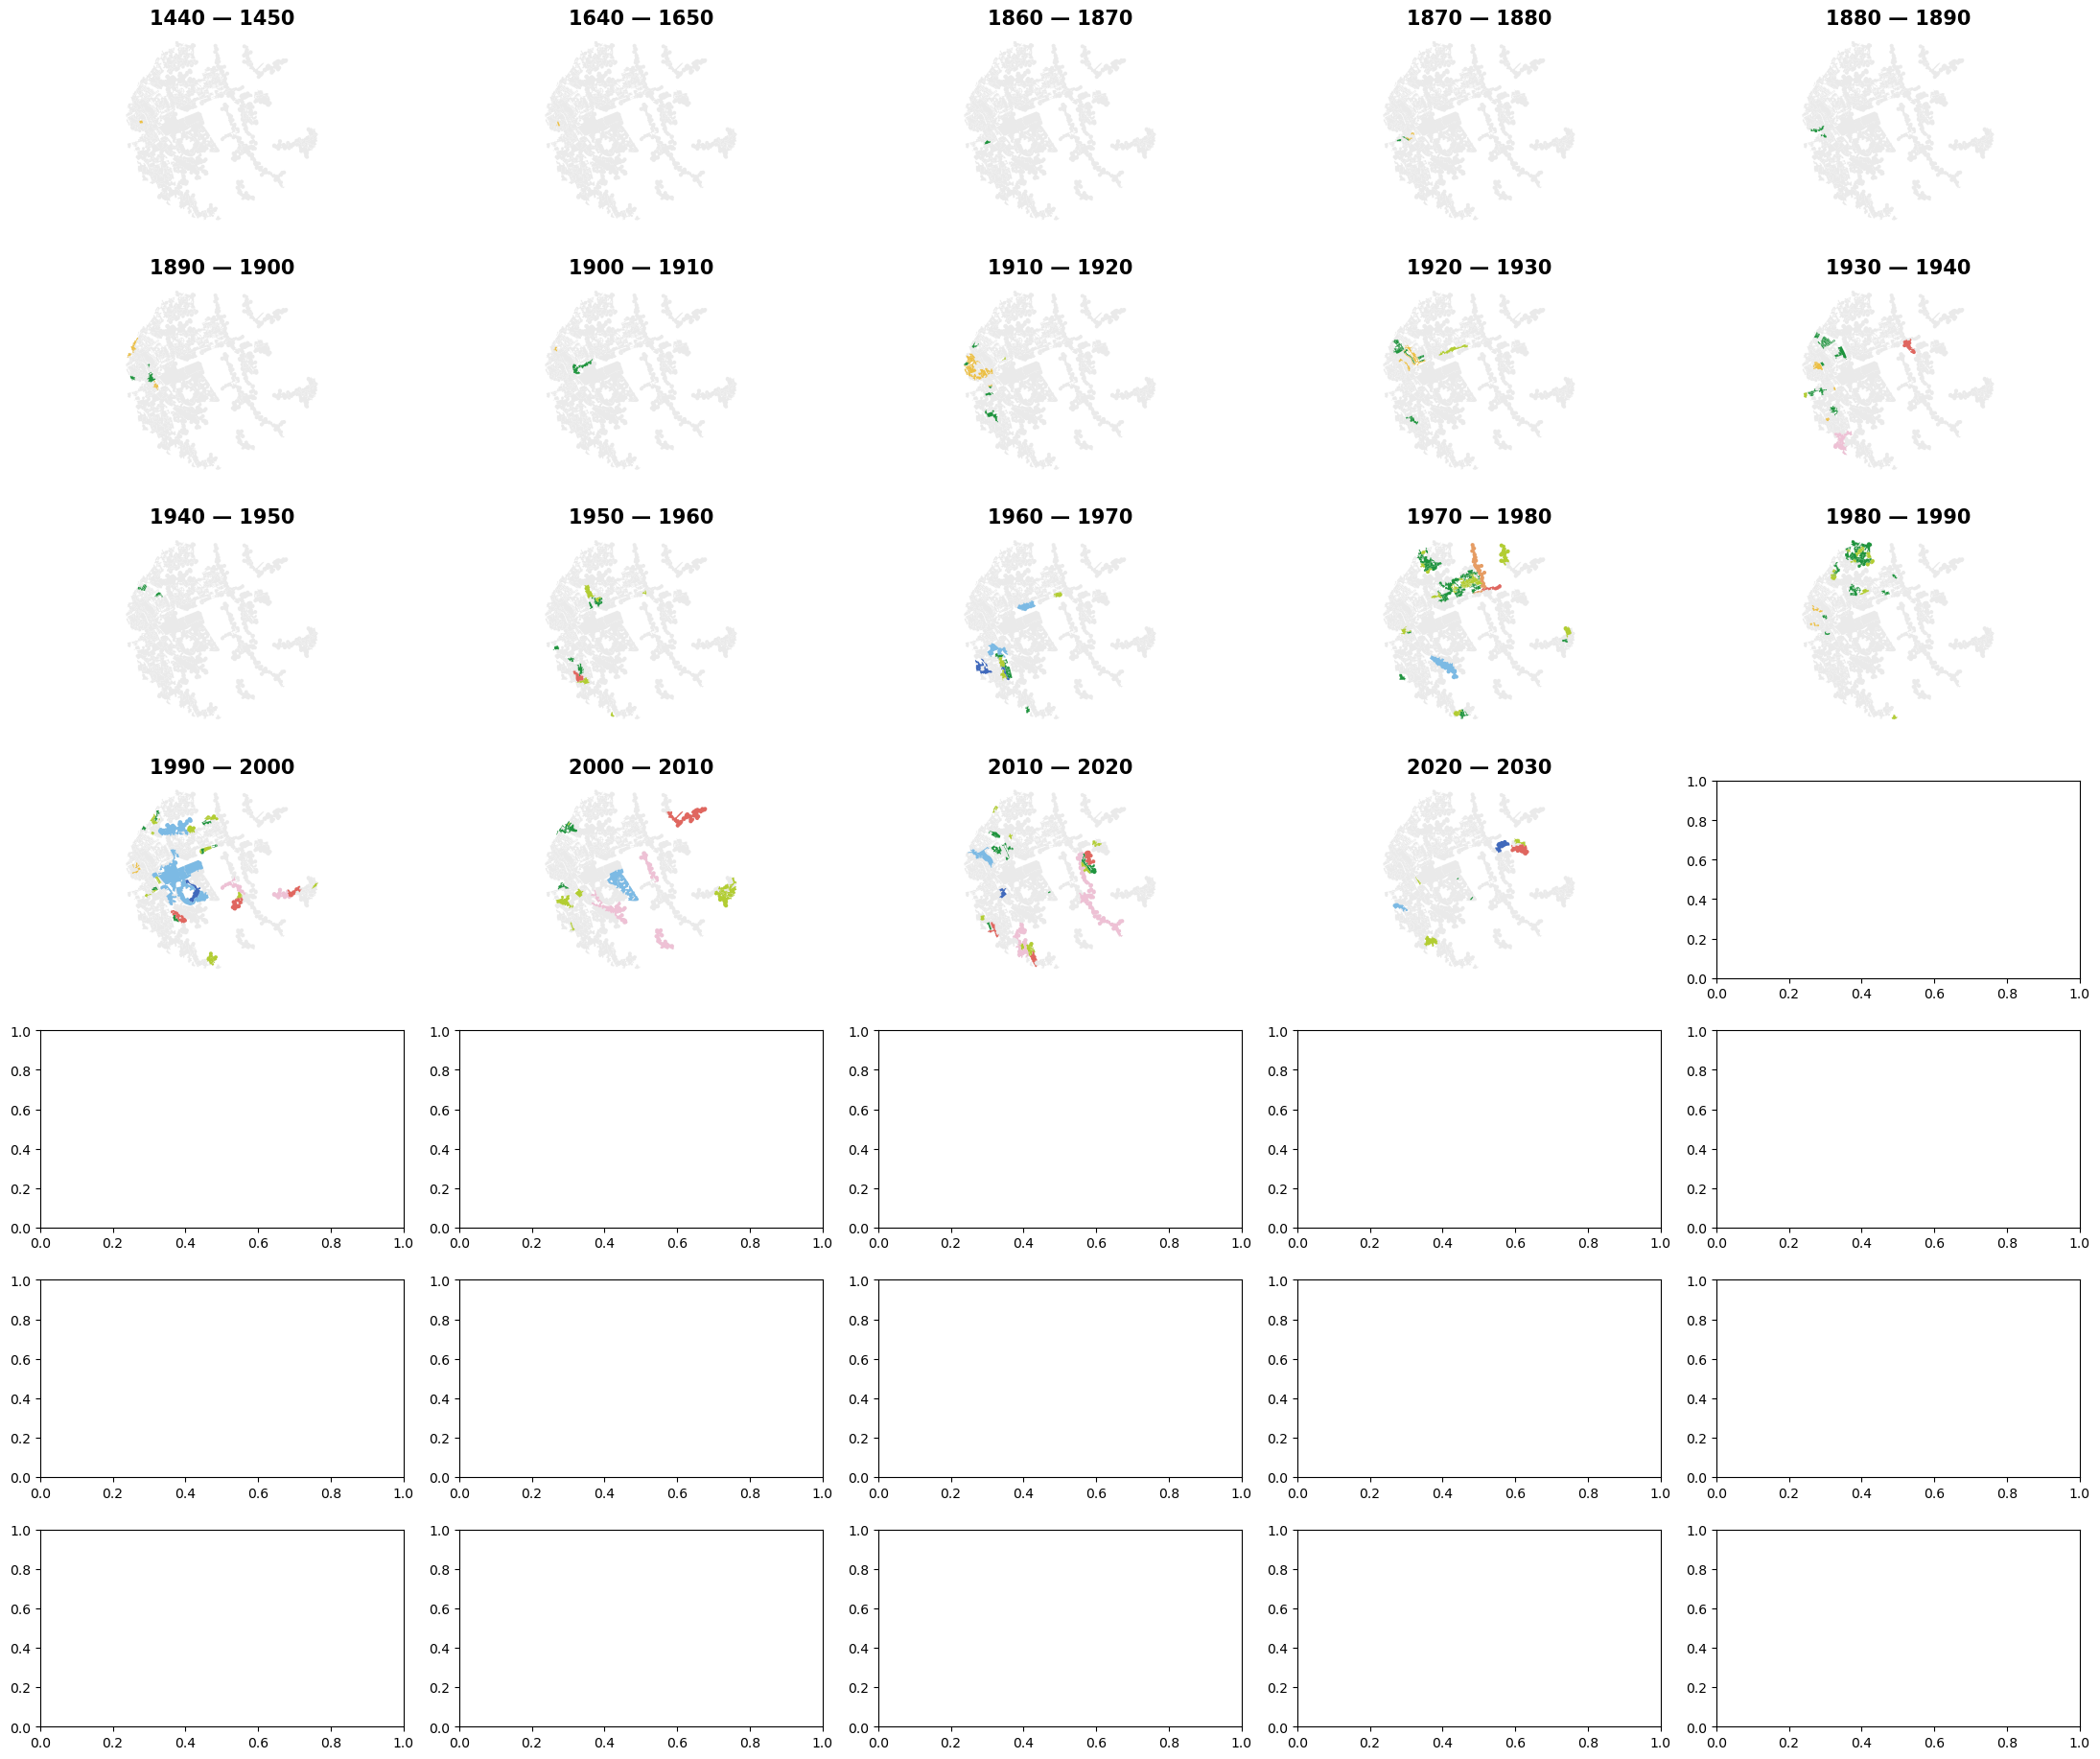

In [23]:
plot_non_cum(groningen)

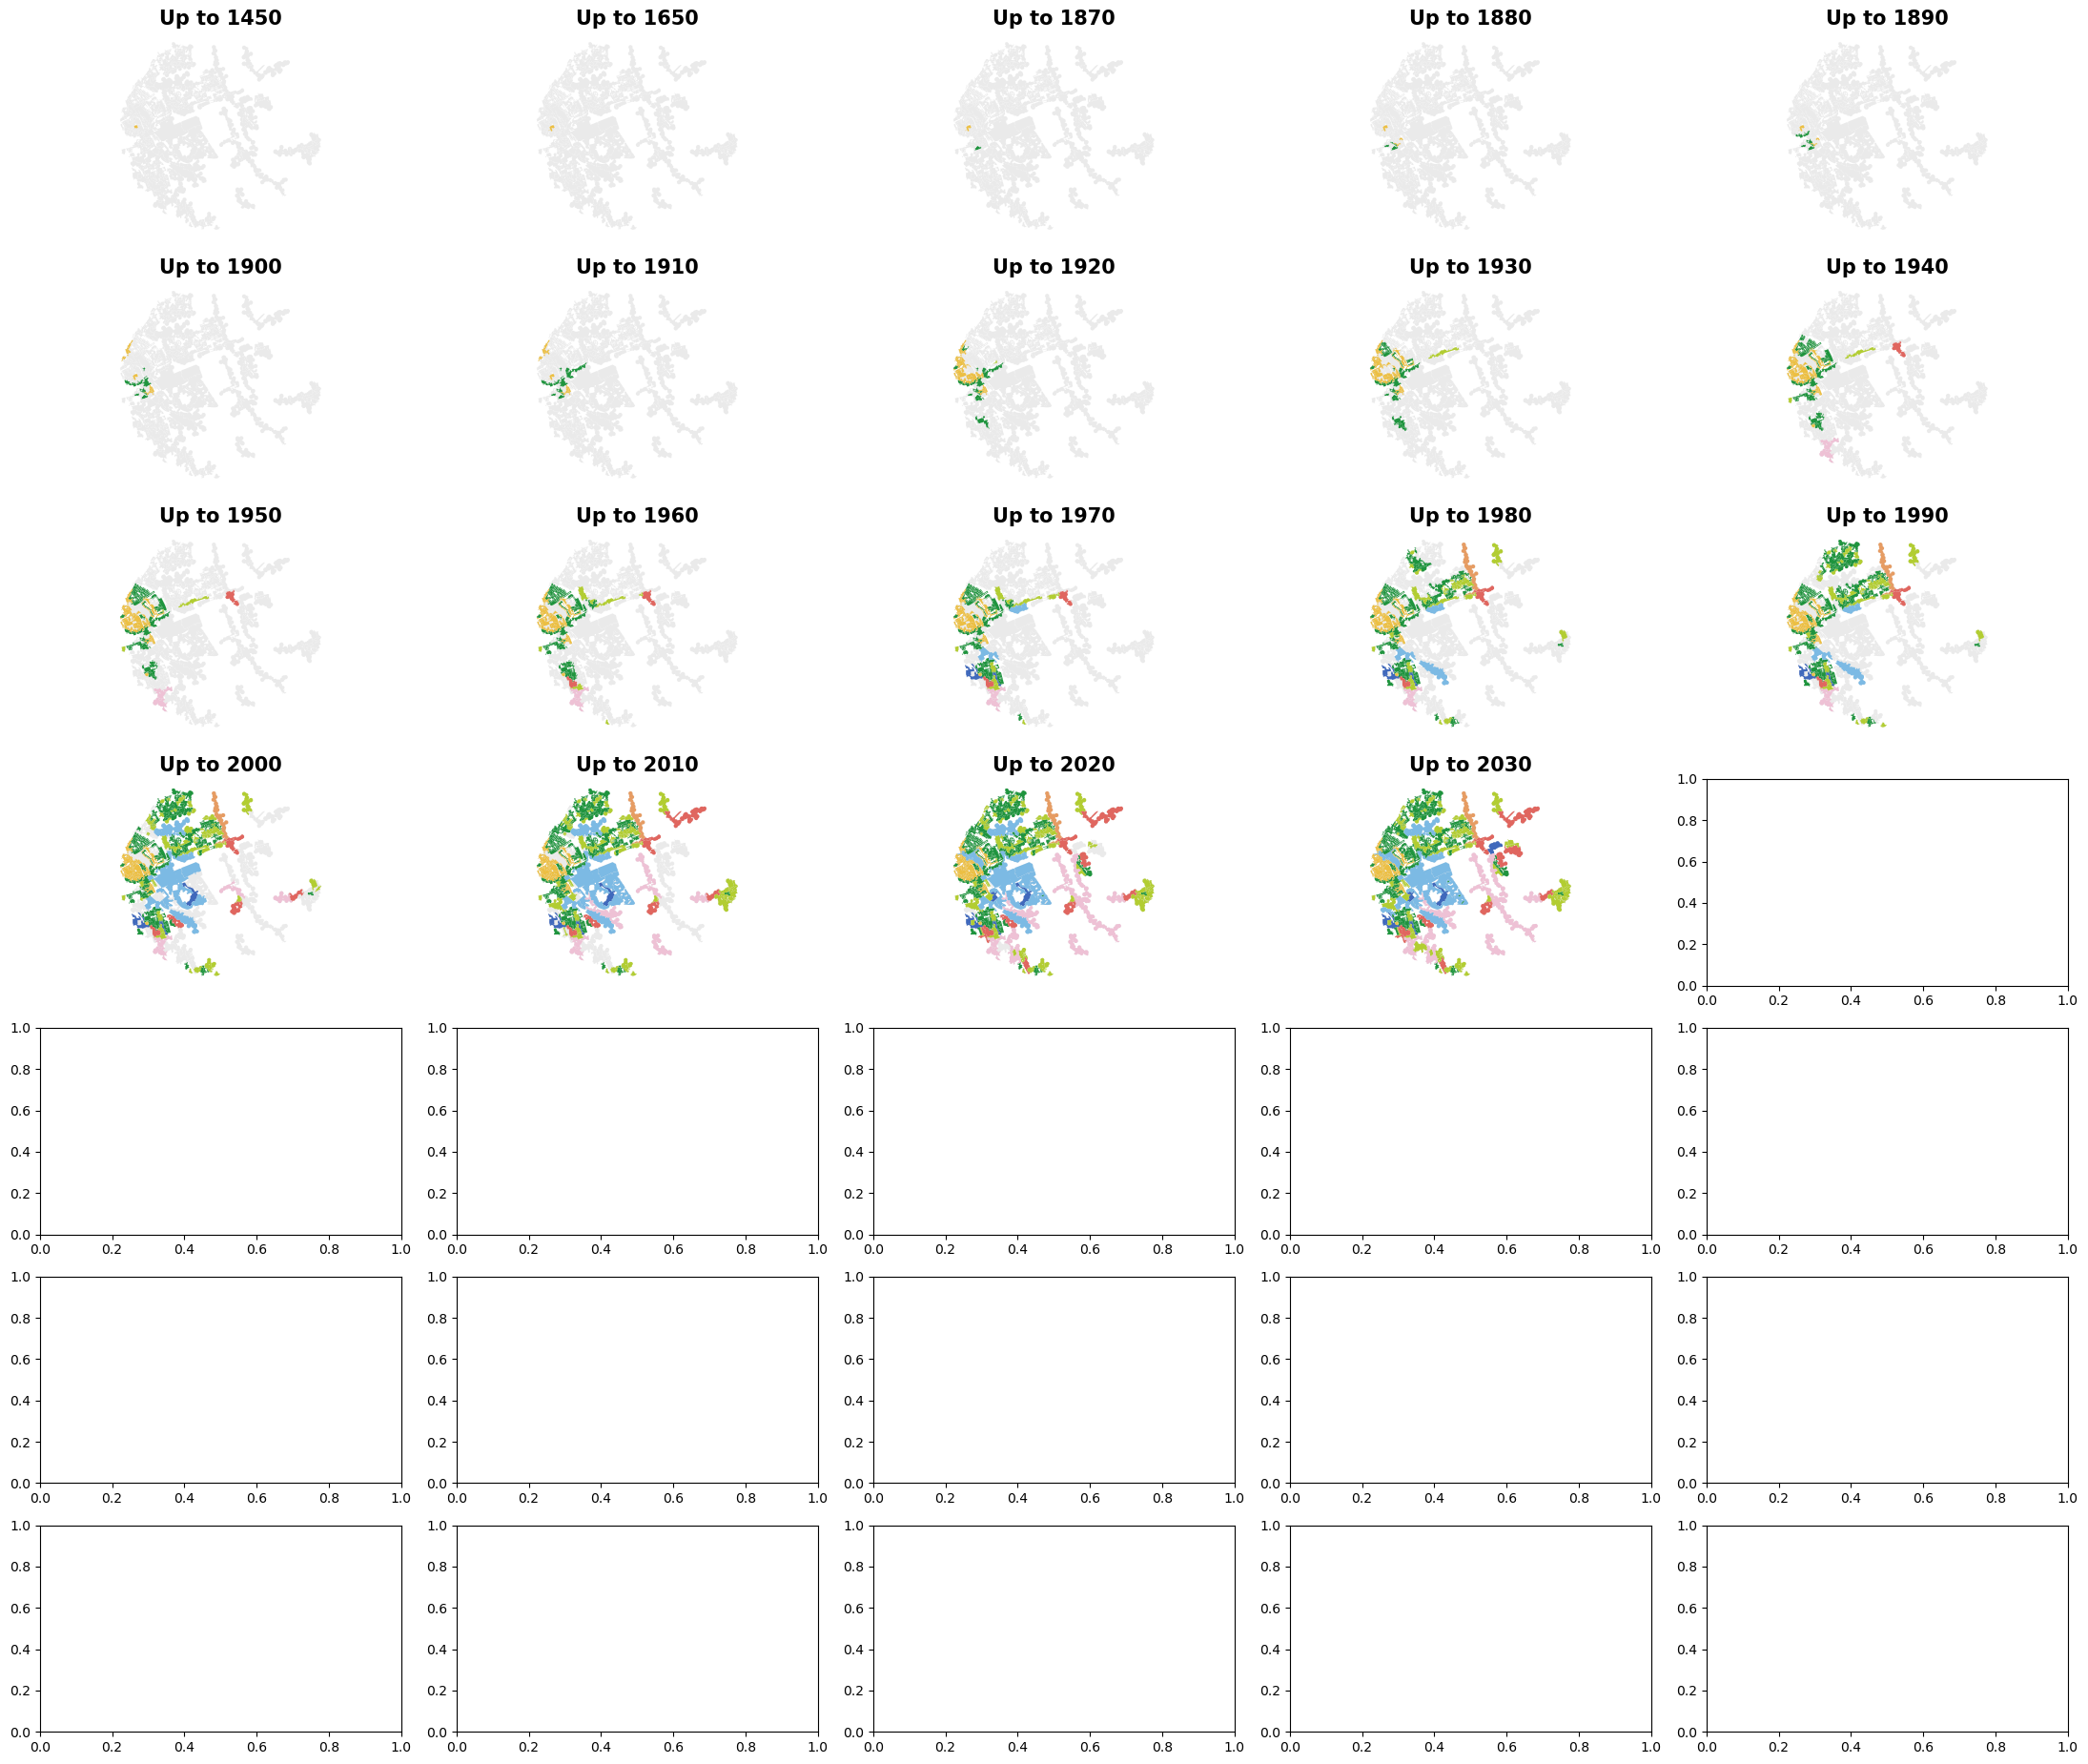

In [24]:
plot_cumulative(groningen)